In [1]:
import numpy as np
import pandas as pd
import os
from scipy.stats import beta
from scipy.special import digamma, polygamma
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution
from GASModels.distributions.za_gb2_log_link import ZAGB2LogLinkDistribution

In [2]:
import numpy as np
from scipy.special import expit
from GASModels.distributions.gb2_log_link import GB2LogLinkDistribution


def iterate_zagb2(
    # φ dynamics
    mu0_phi,
    gamma0_phi,
    gamma_star0_phi,
    alpha_phi,
    kappa_phi,
    kappas_tvp,
    c_phi,
    kappa_gamma_phi,

    # π dynamics
    omega0,
    rho,
    omega_y,

    # GB2 shape (initial values)
    gamma_init,
    xi_init,
    zeta_init,

    harmonics,
    period,
    y,
    time_varying_parameters,
    mode="loglik"
):
    """
    Zero-Augmented GB2 with:
    - GAS φ_t
    - Persistent ARX logit π_t
    - Optional TVP for (gamma, xi, zeta)
    """

    gb2 = GB2LogLinkDistribution()

    T = len(y)
    K = len(omega_y)
    if T <= K:
        raise ValueError("Need T > number of lags K")

    n_eff = T - K

    # ---------- Allocate ----------
    mu_phi = np.zeros(n_eff + 1)
    phi = np.zeros(n_eff)
    eta = np.zeros(n_eff)
    pi = np.zeros(n_eff)

    gamma = np.zeros(n_eff)
    xi = np.zeros(n_eff)
    zeta = np.zeros(n_eff)

    score_phi = np.zeros(n_eff)
    score_gamma = np.zeros(n_eff)
    score_xi = np.zeros(n_eff)
    score_zeta = np.zeros(n_eff)

    # ---------- Initial states ----------
    mu_phi[0] = mu0_phi
    gamma[0] = gamma_init
    xi[0] = xi_init
    zeta[0] = zeta_init

    gamma_phi = gamma0_phi.copy()
    gamma_star_phi = gamma_star0_phi.copy()

    loglik = 0.0

    # ---------- Main loop ----------
    for i, t in enumerate(range(K, T)):

        # ===== 1. Update TVP parameters FIRST =====
        if i > 0:
            gamma[i] = gamma[i-1]
            xi[i] = xi[i-1]
            zeta[i] = zeta[i-1]

            if 2 in time_varying_parameters:
                gamma[i] += kappas_tvp[1] * score_gamma[i-1]
            if 3 in time_varying_parameters:
                xi[i] += kappas_tvp[2] * score_xi[i-1]
            if 4 in time_varying_parameters:
                zeta[i] += kappas_tvp[3] * score_zeta[i-1]

        # validity
        if np.exp(zeta[i]) <= np.exp(gamma[i]):
            return 1e12

        # ===== 2. φ dynamics =====
        phi[i] = mu_phi[i] + np.sum(gamma_phi)

        # ===== 3. π dynamics =====
        y_lags = y[t-K:t][::-1]
        eta[i] = omega0 + rho * (eta[i-1] if i > 0 else 0.0) + np.dot(omega_y, y_lags)
        pi[i] = expit(eta[i])

        if not np.isfinite(phi[i]) or not np.isfinite(pi[i]):
            return 1e12

        # ===== 4. Likelihood =====
        if mode == "loglik":
            if y[t] == 0:
                ll = np.log(1 - pi[i] + 1e-12)
            else:
                ll = np.log(pi[i] + 1e-12) + gb2.logpdf(
                    y[t],
                    phi=phi[i],
                    gamma=gamma[i],
                    xi=xi[i],
                    zeta=zeta[i],
                )

            if not np.isfinite(ll):
                return 1e12

            loglik += ll

        # ===== 5. Scores =====
        if y[t] > 0:
            scores = gb2.score(
                y[t],
                phi=phi[i],
                gamma=gamma[i],
                xi=xi[i],
                zeta=zeta[i],
            )
            score_phi[i], score_gamma[i], score_xi[i], score_zeta[i] = scores
        else:
            score_phi[i] = 0.0
            score_gamma[i] = 0.0
            score_xi[i] = 0.0
            score_zeta[i] = 0.0

        # ===== 6. GAS update for φ =====
        mu_phi[i+1] = c_phi + alpha_phi * mu_phi[i] + kappa_phi * score_phi[i]

        # ===== 7. Seasonal φ =====
        for j in range(harmonics):
            lam = 2 * np.pi * (j + 1) / period
            g = gamma_phi[j]
            gs = gamma_star_phi[j]

            gamma_phi[j] = np.cos(lam) * g + np.sin(lam) * gs + kappa_gamma_phi * score_phi[i]
            gamma_star_phi[j] = np.cos(lam) * gs - np.sin(lam) * g + kappa_gamma_phi * score_phi[i]

    # ---------- Output ----------
    if mode == "loglik":
        return -loglik

    elif mode == "filter":
        return {
            "phi": phi,
            "gamma": gamma,
            "xi": xi,
            "zeta": zeta,
            "pi": pi,
            "eta": eta,
            "mu_phi": mu_phi[:-1],
            "score_phi": score_phi,
        }

    else:
        raise ValueError("mode must be 'loglik' or 'filter'")


In [3]:
def objective_zagb2(theta, y, K, tvp = [], harmonics=10, period=365):

    idx = 0
    
    kappas_tvp = np.zeros(4)

    # φ dynamics
    mu0_phi        = theta[idx]; idx += 1
    c_phi          = theta[idx]; idx += 1
    alpha_phi      = theta[idx]; idx += 1
    kappa_phi      = theta[idx]; idx += 1
    
    # if len(tvp) > 0:
    #     for i, v in enumerate(tvp): 
    #         kappas_tvp[v-1] = theta[idx]; idx += 1
    
    kappa_gamma_phi= theta[idx]; idx += 1

    # π dynamics
    omega0 = theta[idx]; idx += 1
    rho    = theta[idx]; idx += 1
    omega_y = theta[idx:idx+K]; idx += K

    # GB2 shape
    gamma = theta[idx]; idx += 1
    xi    = theta[idx]; idx += 1
    zeta  = theta[idx]; idx += 1

    # φ seasonality
    gamma0_phi = theta[idx:idx+harmonics]; idx += harmonics
    gamma_star0_phi = theta[idx:idx+harmonics]

    return iterate_zagb2(
        mu0_phi=mu0_phi,
        gamma0_phi=gamma0_phi,
        gamma_star0_phi=gamma_star0_phi,
        alpha_phi=alpha_phi,
        kappa_phi=kappa_phi,
        kappas_tvp=kappas_tvp,
        c_phi=c_phi,
        kappa_gamma_phi=kappa_gamma_phi,

        omega0=omega0,
        rho=rho,
        omega_y=omega_y,

        gamma_init=gamma,
        xi_init=xi,
        zeta_init=zeta,

        harmonics=harmonics,
        period=period,
        y=y,
        time_varying_parameters=tvp,
        mode="loglik"
    )


In [4]:
def AIC_zagb2(theta, y, K, tvp=[], harmonics=10, period=365):

    idx = 0
    
    kappas_tvp = np.zeros(4)

    # φ dynamics
    mu0_phi        = theta[idx]; idx += 1
    c_phi          = theta[idx]; idx += 1
    alpha_phi      = theta[idx]; idx += 1
    kappa_phi      = theta[idx]; idx += 1
    
    if len(tvp) > 0:
        for i, v in enumerate(tvp): 
            kappas_tvp[v-1] = theta[idx]; idx += 1
    
    kappa_gamma_phi= theta[idx]; idx += 1

    # π dynamics
    omega0 = theta[idx]; idx += 1
    rho    = theta[idx]; idx += 1
    omega_y = theta[idx:idx+K]; idx += K

    # GB2 shape
    gamma = theta[idx]; idx += 1
    xi    = theta[idx]; idx += 1
    zeta  = theta[idx]; idx += 1

    # φ seasonality
    gamma0_phi = theta[idx:idx+harmonics]; idx += harmonics
    gamma_star0_phi = theta[idx:idx+harmonics]

    loglik = -iterate_zagb2(
        mu0_phi=mu0_phi,
        gamma0_phi=gamma0_phi,
        gamma_star0_phi=gamma_star0_phi,
        alpha_phi=alpha_phi,
        kappa_phi=kappa_phi,
        kappas_tvp=kappas_tvp,
        c_phi=c_phi,
        kappa_gamma_phi=kappa_gamma_phi,

        omega0=omega0,
        rho=rho,
        omega_y=omega_y,

        gamma_init=gamma,
        xi_init=xi,
        zeta_init=zeta,

        harmonics=harmonics,
        period=period,
        y=y,
        time_varying_parameters=tvp,
        mode="loglik"
    )
    
    return 2 * (len(theta) - loglik)


In [5]:
from scipy.optimize import minimize

INPUT = r"C:\\Users\\ilang\\OneDrive\\Documentos\\Ilan\\academia\\dissertação\\data\\inmet\\inmet 250126\\TSLab input"
harmonics = 10
period = 365.25

for i,file in enumerate(os.listdir(INPUT)):
    
    if file.split("_")[-1] == "train.csv" and i==1:
        df = pd.read_csv(os.path.join(INPUT, file), sep=";")
        df['smoothed'] = df['smoothed'].str.replace(",", ".").astype(float).values
        df['PRECIPITACAO TOTAL, DIARIO(mm)'] = df['PRECIPITACAO TOTAL, DIARIO(mm)'].fillna(df['smoothed'])
        
        y = df['PRECIPITACAO TOTAL, DIARIO(mm)'].values
        
        theta0 = np.concatenate([
                np.array([
                    np.log(np.mean(y[y > 0]) + 1e-3),  # mu0_phi
                    0.5,        # c_phi
                    0.95,       # alpha_phi
                    0.01,       # kappa_phi
                    #*[0.01, 0.01],#, 0.01],
                    0.01,       # kappa_gamma_phi

                    -1.0,       # omega0
                    0.5,        # rho

                    0.01, 0.01, 0.01,   # omega_y (K=3)

                    1.2,        # gamma
                    1.2,        # xi
                    5.0         # zeta
                ]),
                np.zeros(harmonics),        # gamma0_phi
                np.zeros(harmonics)         # gamma_star0_phi
            ])
        
        bounds = [
                (-2.0, 4.0),     # mu0_phi
                (0.0, 5.0),      # c_phi
                (0.00, 0.995),   # alpha_phi
                (1e-4, 0.1),     # kappa_phi
                #*[(1e-4, 0.1), (1e-4, 0.1)],#, (-0.1, 0.1), (-0.1, 0.1)],
                (1e-4, 0.1),     # kappa_gamma_phi

                (-10.0, 2.0),    # omega0
                (0.00, 0.99),   # rho

            ] + [(-5.0, 5.0)] * 3 + [   # omega_y

                (0.5, 2.5),      # gamma
                (0.5, 3.0),      # xi
                (2.5, 6.0)       # zeta

            ] + [(-0.5, 0.5)] * harmonics + [(-0.5, 0.5)] * harmonics
        
        aic = []
        results_df = []
        
        for tvp in [[]]: #, [1, 3], [1, 4], [1, 2, 3], [1, 2, 4], [1, 3, 4], [1, 2, 3, 4]]:
            res = minimize(
                objective_zagb2,
                theta0,
                args=(y, 3, tvp, harmonics, period),
                method="L-BFGS-B",
                bounds=bounds,
                options={
                    "disp": True,
                    "maxiter": 500,
                    "gtol": 1e-3,
                    "ftol": 1e-3
                }
            )

C:\Users\ilang\AppData\Local\Temp\ipykernel_47736\1766180720.py:61: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: overflow encountered in exp
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:30: RuntimeWarning: divide by zero encountered in log
  + (np.exp(xi - gamma) - 1) * np.log(y / np.exp(phi))
c:\Users\ilang\OneDrive\Documentos\Ilan\academia\dissertação\python attempt\GASModels\distributions\gb2_log_link.py:34: RuntimeWarning: overflow encountered in exp
  * np.log(1 + (y / np.exp(phi)) ** (np.exp(-gamma)))


In [6]:
import numpy as np
from scipy.special import betainc

def gb2_cdf(y, phi, gamma, xi, zeta):
    """
    CDF of GB2 distribution consistent with GB2LogLinkDistribution
    
    Parameters
    ----------
    y : float or array
        Observation(s), y > 0
    phi : float
        Log-scale parameter (sigma = exp(phi))
    gamma : float
        Shape parameter via p = exp(-gamma)
    xi : float
        Shape parameter via a = exp(xi)
    zeta : float
        Shape parameter via b = exp(zeta)
    """
    a = np.exp(xi)
    b = np.exp(zeta)
    p = np.exp(-gamma)
    sigma = np.exp(phi)

    z = (y / sigma) ** p
    u = z / (1.0 + z)

    return betainc(a, b, u)


In [7]:
idx = 0
K = 3

mu0_phi = res.x[idx]; idx+=1
c_phi = res.x[idx]; idx+=1
alpha_phi = res.x[idx]; idx+=1
kappa_phi = res.x[idx]; idx+=1

#kappa_gamma_tvp = res.x[idx]; idx+=1
#kappa_xi_tvp = res.x[idx]; idx+=1
#kappa_zeta_tvp = res.x[idx]; idx+=1

kappa_gamma_phi = res.x[idx]; idx+=1

omega0 = res.x[idx]; idx+=1
rho = res.x[idx]; idx+=1

omega_y = res.x[idx:idx+K]; idx+=K

gamma_init = res.x[idx]; idx+=1
xi_init = res.x[idx]; idx+=1
zeta_init = res.x[idx]; idx+=1

gamma0_phi = res.x[idx:idx+harmonics]; idx+=harmonics
gamma_star0_phi = res.x[idx:idx+harmonics]


In [8]:
out = iterate_zagb2(
    mu0_phi=mu0_phi,
    gamma0_phi=gamma0_phi,
    gamma_star0_phi=gamma_star0_phi,
    alpha_phi=alpha_phi,
    kappa_phi=kappa_phi,
    kappas_tvp=[],#, kappa_zeta_tvp],
    c_phi=c_phi,
    kappa_gamma_phi=kappa_gamma_phi,

    omega0=omega0,
    rho=rho,
    omega_y=omega_y,

    gamma_init=gamma_init,
    xi_init=xi_init,
    zeta_init=zeta_init,

    harmonics=harmonics,
    period=period,
    y=y,
    time_varying_parameters=tvp,   # ← IMPORTANT
    mode="filter"
)


In [199]:
out

{'phi': array([2.70552505, 3.23819346, 3.12019617, ..., 2.93125837, 2.91530638,
        2.89524094], shape=(3647,)),
 'gamma': array([1.19206888, 1.19206888, 1.19206888, ..., 1.19206888, 1.19206888,
        1.19206888], shape=(3647,)),
 'xi': array([1.21542245, 1.21542245, 1.21542245, ..., 1.21542245, 1.21542245,
        1.21542245], shape=(3647,)),
 'zeta': array([4.97360727, 4.97360727, 4.97360727, ..., 4.97360727, 4.97360727,
        4.97360727], shape=(3647,)),
 'pi': array([0.30412938, 0.27608009, 0.20044216, ..., 0.17136206, 0.16281846,
        0.15623131], shape=(3647,)),
 'eta': array([-0.82771054, -0.96398974, -1.38353313, ..., -1.57600471,
        -1.6374051 , -1.68654071], shape=(3647,)),
 'mu_phi': array([2.67008238, 2.61900003, 2.45143265, ..., 1.79753155, 1.79969987,
        1.80142017], shape=(3647,)),
 'score_phi': array([11.68479672,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ], shape=(3647,))}

In [166]:
print("mu0_phi:", mu0_phi, "gamma0_phi:", gamma0_phi, "gamma_star0_phi:", gamma_star0_phi, "alpha_phi:", alpha_phi, "kappa_phi:", kappa_phi, "kappas_tvp:", [kappa_gamma_tvp], "c_phi:", c_phi, "kappa_gamma_phi:", kappa_gamma_phi, "omega0:", omega0, "rho:", rho, "omega_y:", omega_y, "gamma_init:", gamma_init, "xi_init:", xi_init, "zeta_init:", zeta_init, "gamma0_phi:", gamma0_phi, "gamma_star0_phi:", gamma_star0_phi)

mu0_phi: 2.6700823846401436 gamma0_phi: [-0.0045236   0.00756159  0.00402591  0.00589929  0.00592702 -0.0036815
  0.00522918  0.00491579  0.00478638  0.0053026 ] gamma_star0_phi: [ 0.00414601 -0.00634513 -0.00410227 -0.0055077   0.00421107  0.00287783
 -0.00497787  0.00421977 -0.00481017 -0.00482797] alpha_phi: 0.793375265485598 kappa_phi: 0.010872238817850497 kappas_tvp: [np.float64(0.005607082907639546)] c_phi: 0.3735828051756261 kappa_gamma_phi: 0.005012173730914656 omega0: -0.9534136471516116 rho: 0.44773713408532556 omega_y: [ 0.09033964 -0.01213599  0.00832476] gamma_init: 1.1920688753699327 xi_init: 1.2154224467741601 zeta_init: 4.973607269529821 gamma0_phi: [-0.0045236   0.00756159  0.00402591  0.00589929  0.00592702 -0.0036815
  0.00522918  0.00491579  0.00478638  0.0053026 ] gamma_star0_phi: [ 0.00414601 -0.00634513 -0.00410227 -0.0055077   0.00421107  0.00287783
 -0.00497787  0.00421977 -0.00481017 -0.00482797]


In [9]:
phi_hat = out["phi"]
pi_hat  = out["pi"]
gamma_hat = out["gamma"]
xi_hat = out["xi"]
zeta_hat = out["zeta"]

y_eff = y[K:]

pit = np.zeros(len(y_eff))
rng = np.random.default_rng(123)

for t in range(len(y_eff)):

    if y_eff[t] == 0:
        pit[t] = rng.uniform(0.0, 1.0 - pi_hat[t])
    else:
        F = gb2_cdf(
            y_eff[t],
            phi_hat[t],
            gamma_hat[t],
            xi_hat[t],
            zeta_hat[t]
        )
        pit[t] = (1 - pi_hat[t]) + pi_hat[t] * F


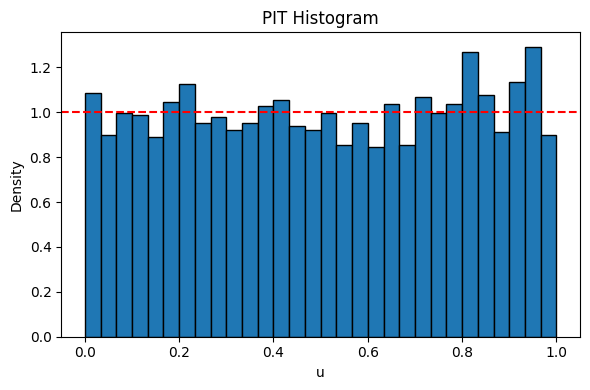

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(pit, bins=30, density=True, edgecolor="k")
plt.axhline(1.0, color="red", linestyle="--")
plt.title("PIT Histogram")
plt.xlabel("u")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

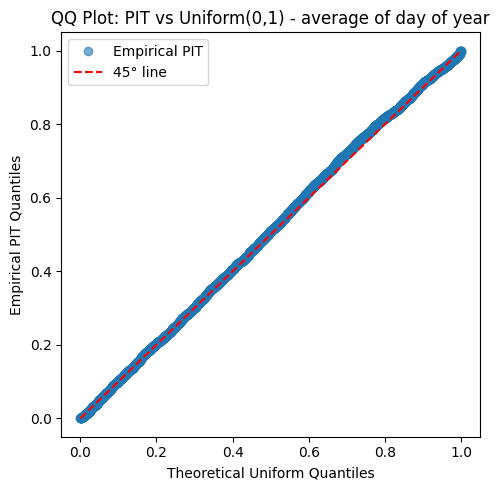

In [11]:
import numpy as np

pit_sorted = np.sort(pit)
n = len(pit_sorted)
u_theoretical = (np.arange(1, n+1) - 0.5) / n

plt.figure(figsize=(5,5))
plt.plot(u_theoretical, pit_sorted, 'o', alpha=0.6, label="Empirical PIT")
plt.plot([0,1], [0,1], 'r--', label="45° line")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical PIT Quantiles")
plt.title("QQ Plot: PIT vs Uniform(0,1) - average of day of year")
plt.legend()
plt.tight_layout()
plt.show()


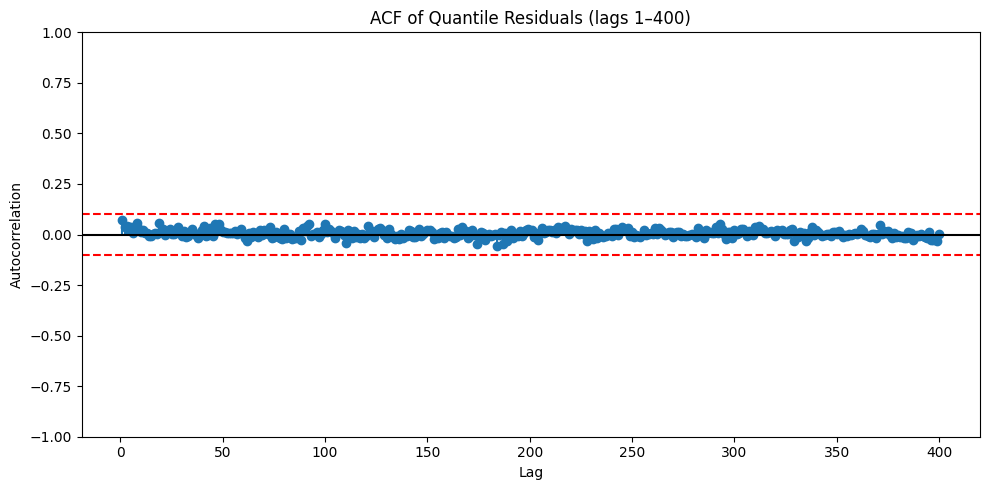

In [189]:
from scipy.stats import norm

qr = norm.ppf(pit)
qr = qr[np.isfinite(qr)]  # safety


from statsmodels.tsa.stattools import acf

nlags = 400
acf_vals = acf(qr, nlags=nlags, fft=True)

acf_vals_no0 = acf_vals[1:]   # drop lag 0
lags = np.arange(1, nlags+1)
conf = 0.1

plt.figure(figsize=(10,5))
plt.stem(lags, acf_vals_no0, basefmt=" ")
plt.axhline(conf, color="red", linestyle="--")
plt.axhline(-conf, color="red", linestyle="--")
plt.axhline(0, color="black")
plt.title("ACF of Quantile Residuals (lags 1–400)")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.ylim((-1.0, 1.0))
plt.tight_layout()
plt.show()
